In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [7]:
class Circle:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        self.load_data()

    def load_data(self):
        self.df = pd.read_csv(self.file_path)
       
    def plotting(self):

        self.circle_matrix = pd.pivot_table(
            self.df,
            index = ['Maze_ID','target_X', 'target_Y','endpoint_X', 'endpoint_Y'],
            fill_value=0,
            aggfunc='size',                            
        )

        self.circle_df = self.circle_matrix.reset_index()
        
        for maze_id, group in self.circle_df.groupby('Maze_ID'):

            fig, ax = plt.subplots(figsize=(6, 6))

            # Circle
            theta = np.linspace(0, 2*np.pi, 150)
            radius = 20
            ax.plot(
                radius*np.cos(theta),
                radius*np.sin(theta),
                color='black',
                linewidth=1,
            )

            # Endpoints
            ax.scatter(
                group['endpoint_X'],
                group['endpoint_Y'],
                c='blue',
                s=50,
                label='Endpoints'
            )

            # Target
            ax.scatter(
                group['target_X'].iloc[0],
                group['target_Y'].iloc[0],
                c='red',
                marker='*',
                s=200,
                label='Target'
            )

            ax.set_title(f'Maze {maze_id}', fontsize=14, pad=15)
            ax.set_aspect('equal')
            ax.set_xlim(-22, 22)
            ax.set_ylim(-22, 22)
            ax.grid(True, linestyle="--", alpha=0.5)
            ax.legend(title="Legend", bbox_to_anchor=(1, 1), loc="upper left")

            plt.show()

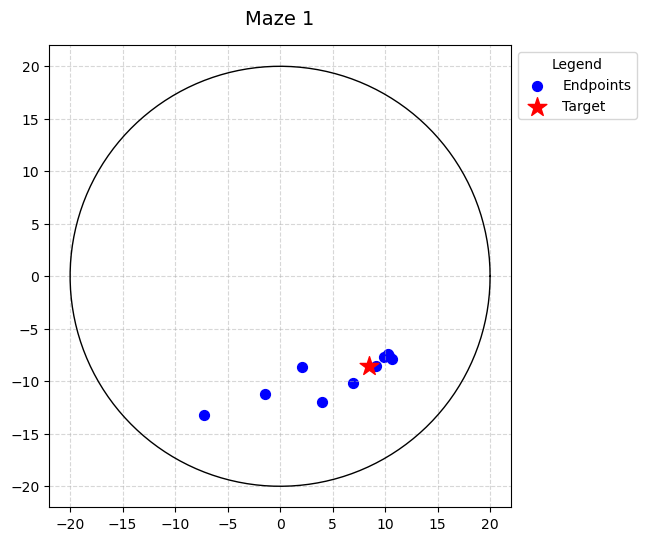

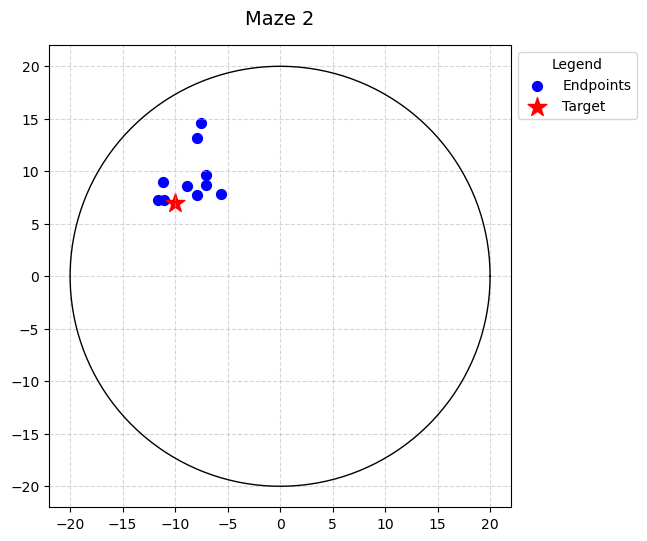

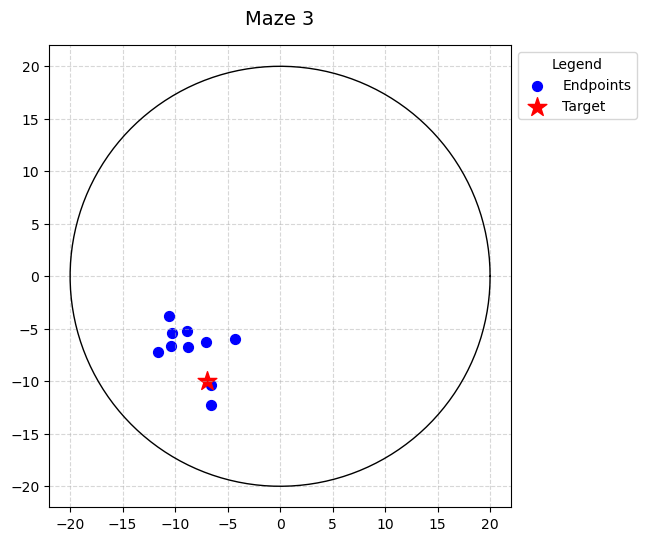

In [10]:
Circle('PID20_SESSION2.csv').plotting()
